# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [ ]:
df= pd.read_csv('data/CleanedAviationData.csv')


Index(['Unnamed: 0', 'Event.Id', 'Investigation.Type', 'Accident.Number',
       'Event.Date', 'Location', 'Country', 'Injury.Severity',
       'Aircraft.damage', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Broad.phase.of.flight', 'Report.Status', 'Publication.Date',
       'Estimated.Total.Passengers', 'Fatal/Serious.Injuries',
       'Aircraft.Destroyed', 'Plane.Type'],
      dtype='object')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [ ]:
df['Aircraft.Size']= 'Large'
df.loc[df['Estimated.Total.Passengers'] <= 20, 'Aircraft.Size'] = 'Small'

0                            Cessna
1                            Cessna
2                            Cessna
3                             Piper
4                            Cessna
                    ...            
62956                         Piper
62957                        Cirrus
62958                    Swearingen
62959                        Cessna
62960    American Champion Aircraft
Name: Make, Length: 62961, dtype: object

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [70]:
make_risk = df.groupby(['Aircraft.Size', 'Make'])['Fatal/Serious.Injuries'].mean()
make_risk = make_risk.reset_index()
small_15 = make_risk[make_risk['Aircraft.Size'] == 'Small'].sort_values('Fatal/Serious.Injuries').head(15)
large_15 = make_risk[make_risk['Aircraft.Size'] == 'Large'].sort_values('Fatal/Serious.Injuries').head(15)
large_15
# plot_df = pd.concat([small_15, large_15])

# plt.figure(figsize=(12,6))
# sns.barplot(data=plot_df, x='Fatal/Serious.Injuries', y='Make', hue='Aircraft.Size')
# plt.title('Lowest 15 Mean Fatal/Serious Injury Makes by Aircraft Size')
# plt.show()

,Aircraft.Size,Make,Fatal/Serious.Injuries
0,Large,Aero Commander,0.000000
17,Large,Swearingen,0.000000
1,Large,Aerospatiale,0.003388
8,Large,Cessna,0.006792
7,Large,Canadair,0.012821
15,Large,Mcdonnell Douglas,0.029269
5,Large,Boeing,0.048378
2,Large,Airbus,0.068167
12,Large,Fairchild,0.073281
6,Large,British Aerospace,0.090909


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

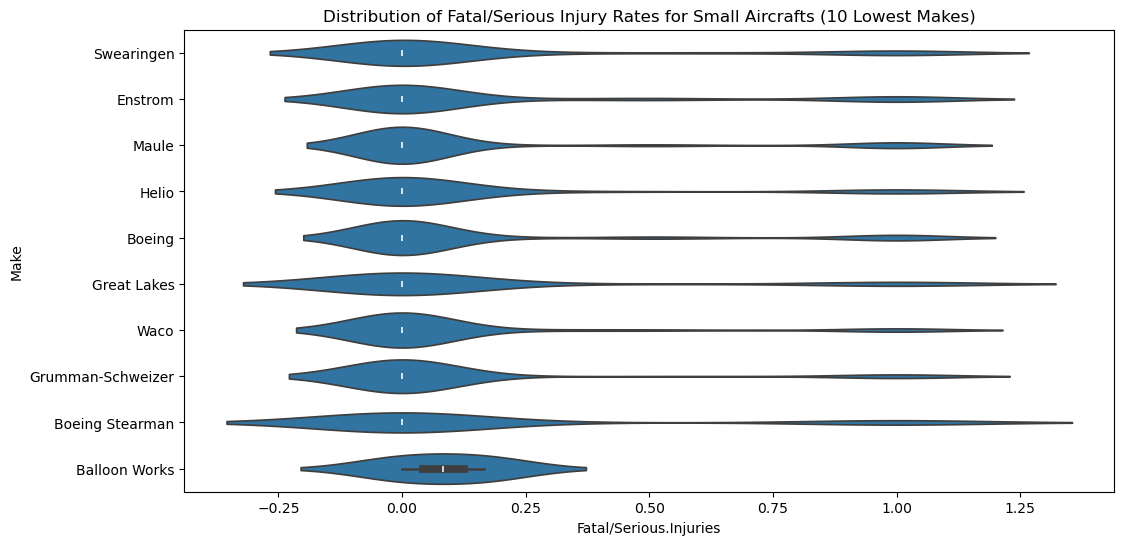

In [ ]:
small_10_makes= make_risk[make_risk['Aircraft.Size'] == 'Small'].sort_values('Fatal/Serious.Injuries').head(10)['Make']
small_filtered= df[(df['Aircraft.Size'] == 'Small') & (df['Make'].isin(small_10_makes))]
plt.figure(figsize=(12,6))
sns.violinplot(data= small_filtered, x= 'Fatal/Serious.Injuries', y= 'Make')
plt.title('Distribution of Fatal/Serious Injury Rates for Small Aircrafts (10 Lowest Makes)')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

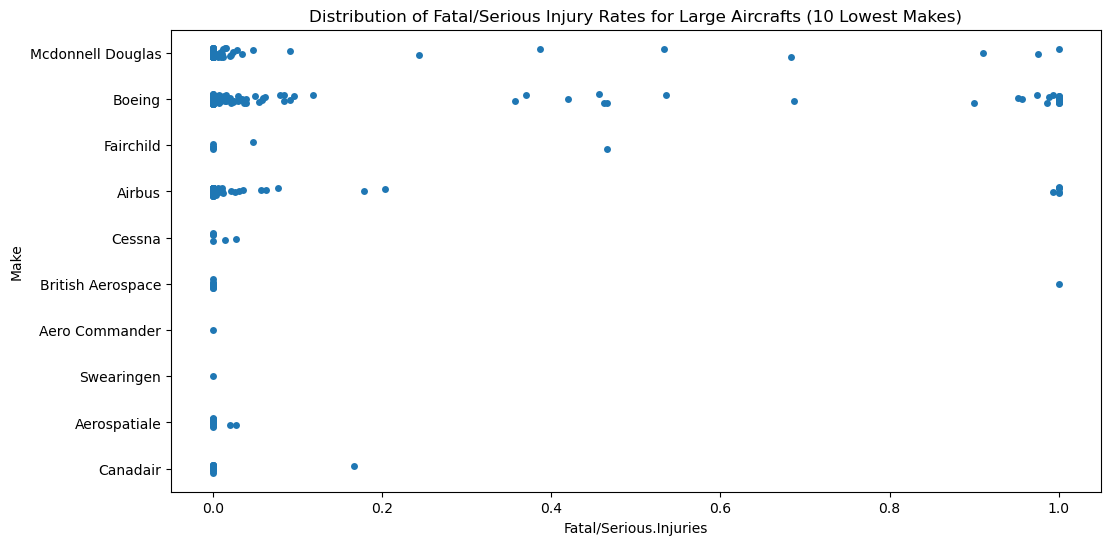

In [67]:
large_10_makes= make_risk[make_risk['Aircraft.Size'] == 'Large'].sort_values('Fatal/Serious.Injuries').head(10)['Make']
large_filtered= df[(df['Aircraft.Size'] == 'Large') & (df['Make'].isin(large_10_makes))]
plt.figure(figsize=(12,6))
sns.stripplot(data= large_filtered, x= 'Fatal/Serious.Injuries', y= 'Make')
plt.title('Distribution of Fatal/Serious Injury Rates for Large Aircrafts (10 Lowest Makes)')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [71]:
aircraft_destruction = df.groupby(['Aircraft.Size', 'Make'])['Aircraft.Destroyed'].mean()
aircraft_destruction = aircraft_destruction.reset_index()
small_destruction = aircraft_destruction[aircraft_destruction['Aircraft.Size'] == 'Small'].sort_values('Aircraft.Destroyed').head(15)
large_destruction = aircraft_destruction[aircraft_destruction['Aircraft.Size'] == 'Large'].sort_values('Aircraft.Destroyed').head(15)
large_destruction

,Aircraft.Size,Make,Aircraft.Destroyed
0,Large,Aero Commander,0.000000
17,Large,Swearingen,0.000000
1,Large,Aerospatiale,0.000000
15,Large,Mcdonnell Douglas,0.045714
5,Large,Boeing,0.053903
2,Large,Airbus,0.070707
7,Large,Canadair,0.076923
11,Large,Embraer,0.080000
6,Large,British Aerospace,0.090909
10,Large,Douglas,0.145833


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [ ]:
""" 
Small Aircrafts
- For small aircrafts, several makes such as Balloon Works, Grumman Acft Eng Cor-Schweizer, and American Champion Aircraft show very low aircraft destruction rates, with some showing near-zero destruction proportions. These makes also tend to have relatively low fatal/serious injury rates.
- The distributions for Fatal/Serious Injury Rates show that most incidents cluster near low injury fractions, but some makes (Boeing Stearman and Swearingen) show wider spreads and occasional higher-severity outliers.

Large Aircrafts
- For large aircrafts, makes such as Aero Commander, Swearingen, and Aerospatiale show the lowest destruction rates (near zero), and also rank among the lowest in fatal/serious injury fractions.
- Major makes such as Aero Commander, Swearingen, and Aerospatiale show the lowest destruction rates (near zero), and also rank among the lowest in fatal/serious injury fractions.
- However, the stripplot shows outliers with injury fractions approaching 1.0, which means that while outcomes are typically non-severe, severe incidents can still occur.
"""


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

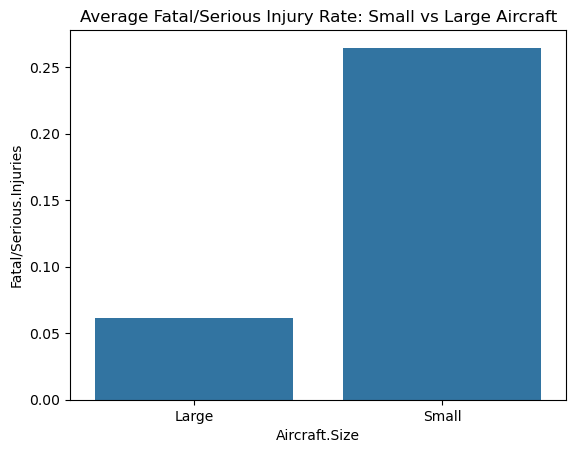

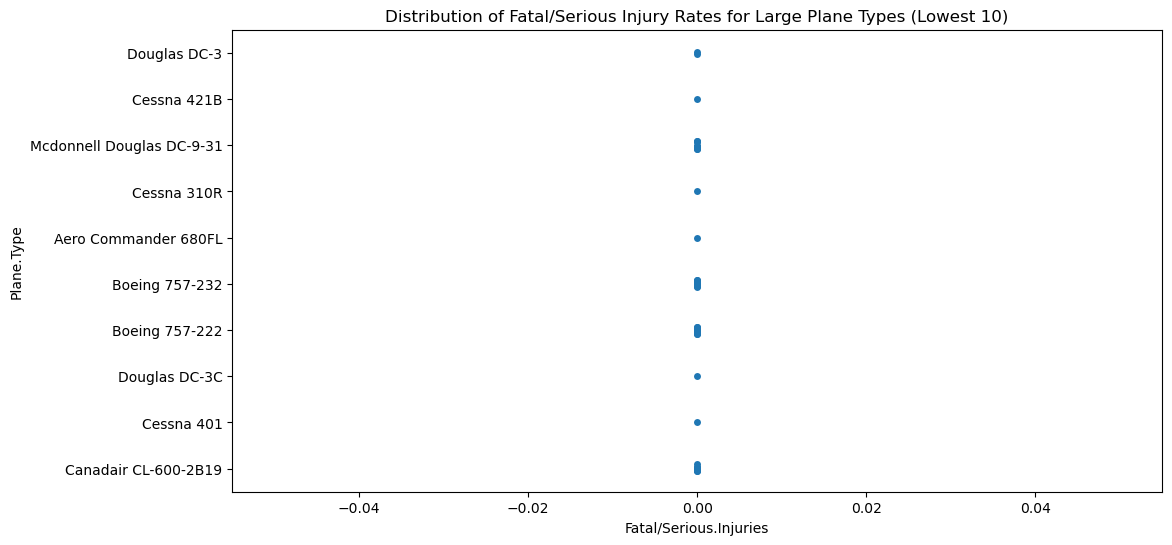

In [94]:
size_means = df.groupby(['Aircraft.Size'])['Fatal/Serious.Injuries'].mean().reset_index()

sns.barplot(data=size_means, x='Aircraft.Size', y='Fatal/Serious.Injuries')
plt.title('Average Fatal/Serious Injury Rate: Small vs Large Aircraft')
plt.show()

plane_counts = df['Plane.Type'].value_counts()
valid_plane_list = plane_counts[plane_counts >= 10].index
valid_planes_filtered = df[df['Plane.Type'].isin(valid_plane_list)]
plane_risk = valid_planes_filtered.groupby(['Aircraft.Size', 'Plane.Type'])['Fatal/Serious.Injuries'].mean().reset_index()

large_planes_risk = plane_risk[plane_risk['Aircraft.Size'] == 'Large'].sort_values('Fatal/Serious.Injuries').head(10)
large_plane_types = large_planes_risk['Plane.Type']
large_filtered = valid_planes_filtered[(valid_planes_filtered['Aircraft.Size'] == 'Large') & (valid_planes_filtered['Plane.Type'].isin(large_plane_types))
]

plt.figure(figsize=(12,6))
sns.stripplot(data=large_filtered, x='Fatal/Serious.Injuries', y='Plane.Type')
plt.title('Distribution of Fatal/Serious Injury Rates for Large Plane Types (Lowest 10)')
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

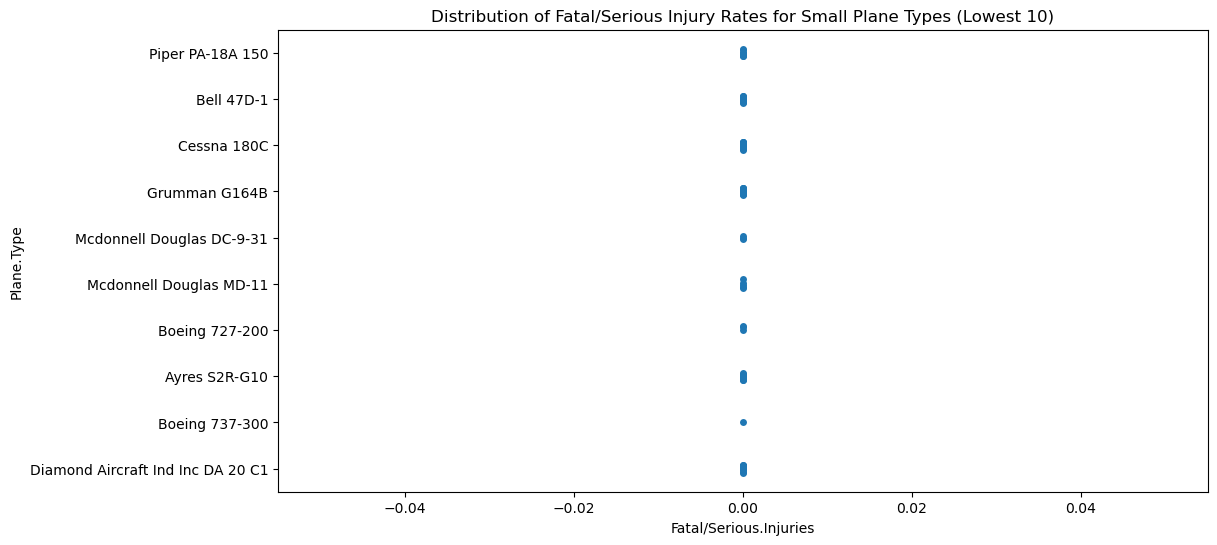

In [96]:
small_planes_risk = plane_risk[plane_risk['Aircraft.Size'] == 'Small'].sort_values('Fatal/Serious.Injuries').head(10)
small_plane_types = small_planes_risk['Plane.Type']
small_filtered = valid_planes_filtered[(valid_planes_filtered['Aircraft.Size'] == 'Small') & (valid_planes_filtered['Plane.Type'].isin(small_plane_types))
]

plt.figure(figsize=(12,6))
sns.stripplot(data=small_filtered, x='Fatal/Serious.Injuries', y='Plane.Type')
plt.title('Distribution of Fatal/Serious Injury Rates for Small Plane Types (Lowest 10)')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [ ]:
"""
The distribution of fatal and serious injury rates for both small and large aircraft types is heavily concentrated at 0. This indicates that, for this sample of the dataset, passengers did not experience serious or fatal injuries regardless of aircraft size or model
"""

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.